
GINI TREND:
  Train: 0.3575
  Test : 0.4000 (+0.0425 vs Train)
  OOT  : 0.3950 (-0.0050 vs Test)

PSI:
  Train vs Test: 0.0186 → STABLE
  Train vs OOT: 0.0156 → STABLE

CSI (FINAL MODEL FEATURES):
  dti_woe: 0.0143 → STABLE
  income_woe: 0.0130 → STABLE
  revol_util_woe: 0.0669 → STABLE
  inq_woe: 0.0571 → STABLE
  purpose_woe: 0.0001 → STABLE
  grade_woe: 0.0111 → STABLE

PD DRIFT:
  Train: 0.1565
  Test : 0.1625
  OOT  : 0.1519

CALIBRATION:
  Delta: 0.1694
  Original PD: 0.1625
  Calibrated PD: 0.1854

VINTAGE PROXY:
  Train bad rate: 0.1565
  Test  bad rate: 0.1854
  OOT   bad rate: 0.2169

MONITORING DECISION:
  FINAL DECISION: NO ACTION REQUIRED


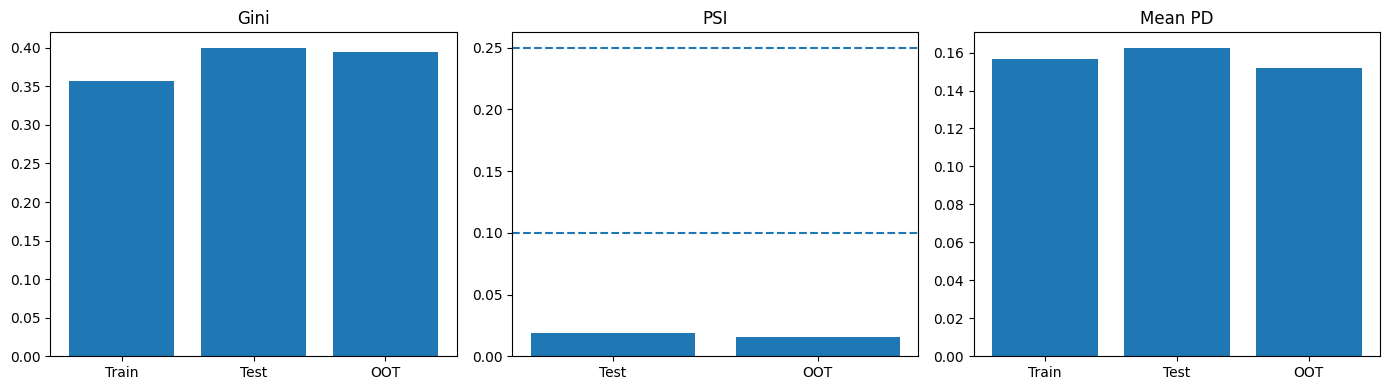


✅ STAGE 6 FINAL — MONITORING SYSTEM COMPLETE


In [9]:
import os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from scipy.special import logit, expit
from scipy.optimize import minimize_scalar

# =========================
# PATHS
# =========================
PROJECT_PATH = r"C:\Users\Harsh Prakash\Desktop\Lending Club Credit Risk Project"
ARTIFACTS_PATH = os.path.join(PROJECT_PATH, "artifacts")

# =========================
# LOAD ARTIFACTS
# =========================
pd_train = pd.read_csv(os.path.join(ARTIFACTS_PATH, "pd_train.csv"))['pd']
pd_test  = pd.read_csv(os.path.join(ARTIFACTS_PATH, "pd_test.csv"))['pd']
pd_oot   = pd.read_csv(os.path.join(ARTIFACTS_PATH, "pd_oot.csv"))['pd']

y_train = pd.read_csv(os.path.join(ARTIFACTS_PATH, "y_train.csv"))['target']
y_test  = pd.read_csv(os.path.join(ARTIFACTS_PATH, "y_test.csv"))['target']
y_oot   = pd.read_csv(os.path.join(ARTIFACTS_PATH, "y_oot.csv"))['target']

# =========================
# 1. GINI FUNCTION
# =========================
def gini(y, p):
    y_bad = 1 - y
    return 2 * roc_auc_score(y_bad, p) - 1

gini_tr  = gini(y_train, pd_train)
gini_te  = gini(y_test, pd_test)
gini_oot = gini(y_oot, pd_oot)

print("\nGINI TREND:")
print(f"  Train: {gini_tr:.4f}")
print(f"  Test : {gini_te:.4f} ({gini_te - gini_tr:+.4f} vs Train)")
print(f"  OOT  : {gini_oot:.4f} ({gini_oot - gini_te:+.4f} vs Test)")

# =========================
# 2. PSI FUNCTION
# =========================
def psi(expected, actual, bins=10):
    expected_bins = pd.qcut(expected, bins, duplicates='drop')
    bin_edges = expected_bins.cat.categories

    actual_bins = pd.cut(actual, bins=bin_edges)

    # out-of-range warning
    n_oor = actual_bins.isna().sum()
    if n_oor > 0:
        print(f"  WARNING: {n_oor} OOT values outside training bins ({n_oor/len(actual):.2%})")

    exp_dist = expected_bins.value_counts(normalize=True).sort_index()
    act_dist = actual_bins.value_counts(normalize=True)\
                          .reindex(exp_dist.index, fill_value=0)

    return ((exp_dist - act_dist) * np.log((exp_dist + 1e-6)/(act_dist + 1e-6))).sum()

psi_test = psi(pd_train, pd_test)
psi_oot  = psi(pd_train, pd_oot)

print("\nPSI:")
for name, val in [("Train vs Test", psi_test), ("Train vs OOT", psi_oot)]:
    flag = "STABLE" if val < 0.1 else ("MODERATE" if val < 0.25 else "REBUILD")
    print(f"  {name}: {val:.4f} → {flag}")

# =========================
# 3. CSI — FINAL MODEL ONLY
# =========================

# CSI computed on WOE-encoded features (model inputs)
X_train = pd.read_csv(os.path.join(ARTIFACTS_PATH, "X_train_model.csv"))
X_oot   = pd.read_csv(os.path.join(ARTIFACTS_PATH, "X_oot_model.csv"))

final_vars = pickle.load(open(os.path.join(ARTIFACTS_PATH, "final_vars_pd.pkl"), "rb"))

def csi(x_train, x_oot, bins=10):
    bins = np.quantile(x_train, np.linspace(0, 1, bins+1))
    bins = np.unique(bins)
    if len(bins) < 3:
        return np.nan

    train_bins = pd.cut(x_train, bins=bins)
    oot_bins   = pd.cut(x_oot, bins=bins)

    train_dist = train_bins.value_counts(normalize=True).sort_index()
    oot_dist   = oot_bins.value_counts(normalize=True)\
                         .reindex(train_dist.index, fill_value=0)

    return ((train_dist - oot_dist) * np.log((train_dist + 1e-6)/(oot_dist + 1e-6))).sum()

print("\nCSI (FINAL MODEL FEATURES):")
for col in final_vars:
    if col not in X_train.columns:
        continue

    val = csi(X_train[col], X_oot[col])

    if np.isnan(val):
        continue

    if val < 0.1:
        flag = "STABLE"
    elif val < 0.25:
        flag = "MODERATE DRIFT"
    else:
        flag = "MAJOR DRIFT — REBUILD"

    print(f"  {col}: {val:.4f} → {flag}")

# =========================
# 4. PD DRIFT
# =========================
print("\nPD DRIFT:")
print(f"  Train: {pd_train.mean():.4f}")
print(f"  Test : {pd_test.mean():.4f}")
print(f"  OOT  : {pd_oot.mean():.4f}")

# =========================
# 5. CALIBRATION (INTERCEPT SHIFT)
# =========================
y_bad = 1 - y_test
logit_pd = logit(pd_test.clip(1e-6, 1 - 1e-6))

def neg_ll(delta):
    pd_adj = expit(logit_pd + delta)
    return -np.sum(
        y_bad * np.log(pd_adj + 1e-10) +
        (1 - y_bad) * np.log(1 - pd_adj + 1e-10)
    )

optim_result = minimize_scalar(neg_ll, bounds=(-3, 3), method='bounded')
delta = optim_result.x

pd_calibrated = expit(logit_pd + delta)

print("\nCALIBRATION:")
print(f"  Delta: {delta:.4f}")
print(f"  Original PD: {pd_test.mean():.4f}")
print(f"  Calibrated PD: {pd_calibrated.mean():.4f}")

# =========================
# 6. VINTAGE PROXY
# =========================
print("\nVINTAGE PROXY:")
print(f"  Train bad rate: {(y_train==0).mean():.4f}")
print(f"  Test  bad rate: {(y_test==0).mean():.4f}")
print(f"  OOT   bad rate: {(y_oot==0).mean():.4f}")

# =========================
# 7. DECISION LOGIC
# =========================
print("\nMONITORING DECISION:")

rebuild = False
recalibrate = False

if psi_oot > 0.25:
    rebuild = True
elif psi_oot > 0.10:
    recalibrate = True

if abs(gini_oot - gini_te) > 0.05:
    rebuild = True

if abs(delta) > 0.3:
    recalibrate = True

if rebuild:
    decision = "FULL REBUILD"
elif recalibrate:
    decision = "RECALIBRATE INTERCEPT"
else:
    decision = "NO ACTION REQUIRED"

print(f"  FINAL DECISION: {decision}")

# =========================
# 8. VISUALS
# =========================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Gini
axes[0].bar(['Train','Test','OOT'], [gini_tr, gini_te, gini_oot])
axes[0].set_title("Gini")

# PSI
axes[1].bar(['Test','OOT'], [psi_test, psi_oot])
axes[1].axhline(0.1, linestyle='--')
axes[1].axhline(0.25, linestyle='--')
axes[1].set_title("PSI")

# PD
axes[2].bar(['Train','Test','OOT'],
            [pd_train.mean(), pd_test.mean(), pd_oot.mean()])
axes[2].set_title("Mean PD")

plt.tight_layout()
plt.show()

print("\n✅ STAGE 6 FINAL — MONITORING SYSTEM COMPLETE")